# Grad-CAM Interpretability

This notebook contains code for qualitative interpretability plots. For each trained model, we visualize what part of the face the model attends to when classifying a clip as real or fake.

**Method per model:**
- **Xception, EfficientNet-B3, hybrid's EfficientNet-B3 backbone, CNN+LSTM's ResNet-18 backbone:** standard Grad-CAM on the last convolutional block of the backbone.
- **ViT-Base/16:** Grad-CAM doesn't transfer naturally to pure-attention models. So, we use the standard adaptation that targets the last transformer block's normalization layer and reshapes the resulting token-level gradients back onto the 14×14 patch grid.

**Sample selection.** We visualize:
- 3 real clips (sampled from the in-domain test split, class = original)
- 3 fake clips from the in-domain test split (one per manipulation: Deepfakes, Face2Face, NeuralTextures. These are seen during training)
- 3 fake clips from the held-out FaceShifter split (unseen during training)

## 1. Setup

In [1]:
# Import nercessary libraries and the shared utilities
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models
import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Import shared utilities
from utils import (
    PREPROCESSED_TENSORS_DIR_PATH,
    RESULTS_DIR_PATH,
    DeepfakeClipDataset,
    load_checkpoint,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

In [2]:
# Set the seed value
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Enable cuDNN auto-tuner to select the fastest convolution algorithms
torch.backends.cudnn.benchmark = True

In [3]:
# Set the device
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU Name is:{torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"
    print("Running on CPU. Grad-CAM will be slow but should still work.")

GPU Name is:NVIDIA GeForce RTX 5080


In [4]:
# Set the output paths
output_dir_path = RESULTS_DIR_PATH / "grad_cam"
output_dir_path.mkdir(parents=True, exist_ok=True)
print(f"Outputs will be saved to: {output_dir_path.resolve()}")

Outputs will be saved to: C:\x-ion\TEST\results\grad_cam


## 2. Pick the sample clips

We sample a fixed set of 9 clips that we'll re-use across all five models.

The middle frame (index 12 out of 24) is what we visualize. Middle frames are usually a safe choice. That is, less risk of edge artifacts from frame sampling, and the manipulation has had time to "warm up" in the clip.

In [5]:
# Load both relevant splits
splits_json_path = PREPROCESSED_TENSORS_DIR_PATH / "splits.json"
assert splits_json_path.exists(), f"Missing {splits_json_path}."

test_dataset = DeepfakeClipDataset(
    splits_json_path, "test", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False
)
faceshifter_dataset = DeepfakeClipDataset(
    splits_json_path, "heldout", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False
)

# Group test split samples by class for easy picking
samples_by_class = {}
for idx, sample in enumerate(test_dataset.samples):
    samples_by_class.setdefault(sample["class_name"], []).append(idx)

print("Test split sample counts per class:")
for class_name, idxs in samples_by_class.items():
    print(f"  {class_name:<20} {len(idxs)}")
print(f"\nFaceShifter sample count: {len(faceshifter_dataset)}")

Test split sample counts per class:
  original             70
  Deepfakes            71
  Face2Face            70
  FaceSwap             70
  NeuralTextures       70

FaceShifter sample count: 400


In [6]:
# Pick 3 real (original) and 3 fake from the in-domain test split (one per manipulation we want to show)
# and 3 FaceShifter clips.

# We want to make sure the chosen real and chosen fake samples are different identities
# so the figures look diverse. But the simplest pick is just the first three after shuffling.

def pick_indices(candidate_indices, k=3):
    """
    This function shuffles deterministically and returns the first k indices.
    """
    candidates = list(candidate_indices)
    random_number_generator = random.Random(SEED)
    random_number_generator.shuffle(candidates)
    return candidates[:k]


# In-domain real clips
real_test_indices = pick_indices(samples_by_class.get("original", []), k=3)

# In-domain fake clips: pick one each from Deepfakes, Face2Face, NeuralTextures
fake_test_indices = []
for manipulation_name in ["Deepfakes", "Face2Face", "NeuralTextures"]:
    pool = samples_by_class.get(manipulation_name, [])
    if len(pool) > 0:
        random_number_generator = random.Random(SEED + hash(manipulation_name) % 1000)
        idx = random_number_generator.choice(pool)
        fake_test_indices.append(idx)

# FaceShifter clips (heldout)
faceshifter_indices = pick_indices(range(len(faceshifter_dataset)), k=3)

print("Picked sample indices:")
print(f"Real (original): {real_test_indices}")
print(f"Fake (in-domain): {fake_test_indices}")
print(f"FaceShifter (held): {faceshifter_indices}")

# Show the class name + tensor path for each
print("\nReal clips:")
for i in real_test_indices:
    s = test_dataset.samples[i]
    print(f" --- [{i}] {s['class_name']:<15} {s['tensor_path']}")
print("\nFake clips (in-domain):")
for i in fake_test_indices:
    s = test_dataset.samples[i]
    print(f" --- [{i}] {s['class_name']:<15} {s['tensor_path']}")
print("\nFaceShifter clips (heldout):")
for i in faceshifter_indices:
    s = faceshifter_dataset.samples[i]
    print(f" --- [{i}] {s['class_name']:<15} {s['tensor_path']}")

Picked sample indices:
Real (original): [15, 66, 6]
Fake (in-domain): [136, 141, 343]
FaceShifter (held): [249, 94, 158]

Real clips:
 --- [15] original        original/645.pt
 --- [66] original        original/696.pt
 --- [6] original        original/636.pt

Fake clips (in-domain):
 --- [136] Deepfakes       Deepfakes/695_422.pt
 --- [141] Face2Face       Face2Face/630_623.pt
 --- [343] NeuralTextures  NeuralTextures/692_610.pt

FaceShifter clips (heldout):
 --- [249] FaceShifter     FaceShifter/249_280.pt
 --- [94] FaceShifter     FaceShifter/094_111.pt
 --- [158] FaceShifter     FaceShifter/158_379.pt


## 3. Helper functions

In [7]:
# Pre-compute ImageNet normalization tensors for denormalization
imagenet_mean_tensor = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
imagenet_std_tensor = torch.tensor(IMAGENET_STD).view(3, 1, 1)


def get_frame_and_clip(dataset, sample_index, frame_index=12):
    """
    This function loads a clip from the dataset and returns:
        - clip: [1, T, 3, H, W] on CPU, normalized
        - frame_normalized: [1, 3, H, W] on CPU, normalized
        - frame_rgb_zero_to_one: numpy [H, W, 3] in [0,1] for overlay
        - label and class_name
    """
    clip, label, metadata = dataset[sample_index]
    # clip has shape [T, 3, H, W]. We will work with the chosen frame.
    frame_normalized = clip[frame_index]  # [3, H, W]
    
    # Denormalize back to [0, 1] for visualization
    frame_zero_to_one = frame_normalized * imagenet_std_tensor + imagenet_mean_tensor
    frame_zero_to_one = frame_zero_to_one.clamp(0, 1)
    
    # Convert to numpy HWC for the overlay function
    frame_rgb_zero_to_one = frame_zero_to_one.permute(1, 2, 0).numpy()
    
    # Add batch dim for the model
    clip_batched = clip.unsqueeze(0)  # [1, T, 3, H, W]
    frame_batched = frame_normalized.unsqueeze(0)  # [1, 3, H, W]
    
    return {
        "clip": clip_batched,
        "frame_normalized": frame_batched,
        "frame_rgb": frame_rgb_zero_to_one,
        "label": label,
        "class_name": metadata["class_name"],
    }

In [8]:
@torch.no_grad()
def get_clip_probability(model, clip, device):
    """
    This function returns the model's predicted fake probability for a full clip.
    """
    model.eval()
    clip = clip.to(device)
    logits = model(clip).squeeze(-1)
    probability = torch.sigmoid(logits.float()).cpu().item()
    return probability

## 4. Model class definitions

Same five classes as in other notebooks. For Grad-CAM, we also need a **single-frame wrapper** for the CNN-only models so the GradCAM library can compute gradients on one frame's prediction (not the averaged clip-level prediction). We do this by wrapping just the `backbone` of each CNN model.

Each model's code is replicated from its relevant notebook.

In [9]:
# Xception (from 03_baseline_xception.ipynb)
class XceptionFrameAverager(nn.Module):
    """Run Xception on each frame independently, average the logits to get a clip score."""
    
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model("legacy_xception", pretrained=pretrained, num_classes=1)
    
    def forward(self, clip):
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        per_frame_logits = self.backbone(flat_frames)
        per_frame_logits = per_frame_logits.view(batch_size, number_of_frames, -1)
        clip_logits = per_frame_logits.mean(dim=1)
        return clip_logits

In [10]:
# EfficientNet-B3 (from 04_baseline_efficientnet.ipynb)
class EfficientNetFrameAverager(nn.Module):
    """Run EfficientNet-B3 on each frame independently, average the logits to get a clip score."""
    
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model("tf_efficientnet_b3", pretrained=pretrained, num_classes=1)
    
    def forward(self, clip):
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        per_frame_logits = self.backbone(flat_frames)
        per_frame_logits = per_frame_logits.view(batch_size, number_of_frames, -1)
        clip_logits = per_frame_logits.mean(dim=1)
        return clip_logits

In [11]:
# CNN + BiLSTM (from 05_baseline_cnn_lstm.ipynb)
class CnnLstmClipModel(nn.Module):
    """ResNet-18 features per frame, then a 2-layer BiLSTM over the 24 frames, then a binary head."""
    
    def __init__(self, lstm_hidden_size=256, lstm_num_layers=2, lstm_dropout=0.3, pretrained=True):
        super().__init__()
        resnet_weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        resnet = models.resnet18(weights=resnet_weights)
        self.feature_dim = resnet.fc.in_features
        resnet.fc = nn.Identity()
        self.cnn_feature_extractor = resnet
        
        self.bilstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout if lstm_num_layers > 1 else 0.0,
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    
    def forward(self, clip):
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        per_frame_features = self.cnn_feature_extractor(flat_frames)
        per_frame_features = per_frame_features.view(batch_size, number_of_frames, self.feature_dim)
        
        lstm_output, (final_hidden, _) = self.bilstm(per_frame_features)
        forward_last = final_hidden[-2]
        backward_last = final_hidden[-1]
        clip_representation = torch.cat([forward_last, backward_last], dim=1)
        clip_logits = self.classifier(clip_representation)
        return clip_logits

In [12]:
# ViT-Base/16 (from 06_baseline_vit.ipynb)
class ViTFrameAverager(nn.Module):
    """Run ViT-Base/16 on each frame independently, average the logits to get a clip score."""
    
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model("vit_base_patch16_224", pretrained=pretrained, num_classes=1)
    
    def forward(self, clip):
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        per_frame_logits = self.backbone(flat_frames)
        per_frame_logits = per_frame_logits.view(batch_size, number_of_frames, -1)
        clip_logits = per_frame_logits.mean(dim=1)
        return clip_logits

In [13]:
# Proposed: Hybrid CNN-Transformer (from 07_proposed_hybrid_cnn_transformer.ipynb)
class HybridCNNTransformer(nn.Module):
    """EfficientNet-B3 per-frame backbone, then a Transformer encoder over the frame sequence with a CLS token."""
    
    def __init__(
        self,
        pretrained=True,
        number_of_frames=24,
        number_of_transformer_layers=4,
        number_of_heads=8,
        transformer_feedforward_dimensions=2048,
        dropout=0.1,
    ):
        super().__init__()
        self.backbone = timm.create_model("tf_efficientnet_b3", pretrained=pretrained, num_classes=0)
        feature_dimensions = self.backbone.num_features
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, feature_dimensions))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.positional_embeddings = nn.Parameter(torch.zeros(1, number_of_frames + 1, feature_dimensions))
        nn.init.trunc_normal_(self.positional_embeddings, std=0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=feature_dimensions,
            nhead=number_of_heads,
            dim_feedforward=transformer_feedforward_dimensions,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=number_of_transformer_layers)
        self.transformer_norm = nn.LayerNorm(feature_dimensions)
        
        self.classifier = nn.Sequential(
            nn.Linear(feature_dimensions, feature_dimensions // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(feature_dimensions // 2, 1),
        )
    
    def forward(self, clip):
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        frame_features = self.backbone(flat_frames)
        frame_features = frame_features.view(batch_size, number_of_frames, -1)
        
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        sequence = torch.cat([cls_tokens, frame_features], dim=1)
        sequence = sequence + self.positional_embeddings
        
        sequence = self.transformer_encoder(sequence)
        sequence = self.transformer_norm(sequence)
        
        cls_output = sequence[:, 0]
        clip_logits = self.classifier(cls_output)
        return clip_logits

## 5. Frame-level wrappers for Grad-CAM

Grad-CAM needs a model that takes a single frame `[B, 3, H, W]` and outputs a single logit. Our trained models take a full clip `[B, T, 3, H, W]`. So, we wrap each one to expose just the backbone's per-frame prediction.

For Xception, EfficientNet, and ViT, the wrapper is simple. Just call `self.backbone(frame)` since their backbones already output a single logit per frame.

For CNN+LSTM and the hybrid, the backbone outputs features (not logits). So, we need to just visualize the CNN backbone's features (what regions it pulls features from).

In [14]:
class SingleFrameLogitWrapper(nn.Module):
    """For Xception, EfficientNet, ViT. Just exposes backbone(frame) -> [B, 1] logit."""
    
    def __init__(self, original_model):
        super().__init__()
        self.backbone = original_model.backbone
    
    def forward(self, frame):
        # frame: [B, 3, H, W]
        return self.backbone(frame)  # [B, 1]


class SingleFrameFeatureMeanWrapper(nn.Module):
    """For CNN+LSTM's ResNet-18 and hybrid's EfficientNet-B3. 
    The backbone outputs a feature vector (not a logit). We return its mean so Grad-CAM has a scalar to differentiate."""
    
    def __init__(self, feature_extractor):
        super().__init__()
        self.feature_extractor = feature_extractor
    
    def forward(self, frame):
        features = self.feature_extractor(frame)  # [B, feature_dim]
        return features.mean(dim=1, keepdim=True)  # [B, 1]

## 6. Identify the Grad-CAM target layer for each model

We pick the last spatial layer before pooling for each backbone. For ViT we pick the last transformer block's normalization layer and use the patch-grid reshape transform.

In [15]:
def reshape_vit_transform(tensor):
    """For ViT-Base/16 at 224x224: 196 patches + 1 CLS = 197 tokens. Drop CLS, reshape to 14x14."""
    # tensor: [B, 197, D]
    result = tensor[:, 1:, :]  # drop CLS
    result = result.reshape(tensor.size(0), 14, 14, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)  # [B, D, 14, 14]
    return result


def get_grad_cam_target_layers(model_name, wrapped_model):
    """This function returns the target layer list and (optional) reshape transform for Grad-CAM."""
    if model_name == "xception_baseline":
        # timm legacy_xception: the last conv block exit point
        return [wrapped_model.backbone.conv4], None
    elif model_name == "efficientnet_b3_baseline":
        # tf_efficientnet_b3: blocks[-1] is the last MBConv stage
        return [wrapped_model.backbone.blocks[-1]], None
    elif model_name == "cnn_lstm_baseline":
        # ResNet-18: layer4 is the last conv stage
        return [wrapped_model.feature_extractor.layer4[-1]], None
    elif model_name == "vit_base_baseline":
        # ViT-Base/16: last transformer block's norm1
        return [wrapped_model.backbone.blocks[-1].norm1], reshape_vit_transform
    elif model_name == "hybrid_cnn_transformer":
        # The backbone is EfficientNet-B3 (same as the EfficientNet baseline)
        return [wrapped_model.feature_extractor.blocks[-1]], None
    else:
        raise ValueError(f"Unknown model name: {model_name}")

## 7. Run Grad-CAM for one model on one sample

This function performs the main flow for each model and sample. It loads the model, builds a frame-level wrapper, runs Grad-CAM, and produces both the heatmap array and the overlay image.

In [16]:
def compute_grad_cam_for_sample(model, wrapped_model, target_layers, reshape_transform, sample_info, device):
    """
    This function runs Grad-CAM on a single frame using the given wrapped model.
    Returns:
        overlay_image (numpy HWC in [0, 1])
        clip_probability (the FULL clip-level probability from the original model)
    """
    frame_tensor = sample_info["frame_normalized"].to(device)
    frame_rgb = sample_info["frame_rgb"]
    
    # Get the clip-level prediction first (this is what the model "thinks" overall)
    clip_probability = get_clip_probability(model, sample_info["clip"], device)
    
    # Run Grad-CAM
    wrapped_model.eval()
    cam = GradCAM(
        model=wrapped_model,
        target_layers=target_layers,
        reshape_transform=reshape_transform,
    )
    # targets=None means: differentiate w.r.t. the model's output (which is a scalar per sample)
    grayscale_cam = cam(input_tensor=frame_tensor, targets=None)[0]  # [H, W] in [0, 1]
    
    # Overlay on the original RGB frame
    overlay_image = show_cam_on_image(frame_rgb, grayscale_cam, use_rgb=True)
    overlay_image = overlay_image.astype(np.float32) / 255.0  # back to [0, 1]
    
    return overlay_image, clip_probability

## 8. Run Grad-CAM for every (model, sample) pair

We loop over the five models and the nine samples (3 real + 3 in-domain fake + 3 FaceShifter). Then, we save the overlays and the predicted probabilities.

In [17]:
# Sample registry: each entry is (source_label, sample_index, dataset_handle)
sample_registry = []
for i in real_test_indices:
    sample_registry.append({"source": "real_test", "index": i, "dataset": test_dataset})
for i in fake_test_indices:
    sample_registry.append({"source": "fake_test", "index": i, "dataset": test_dataset})
for i in faceshifter_indices:
    sample_registry.append({"source": "faceshifter", "index": i, "dataset": faceshifter_dataset})

print(f"Total samples to visualize: {len(sample_registry)}")

# Pre-load all sample info once
loaded_samples = []
for sample_descriptor in sample_registry:
    sample_info = get_frame_and_clip(
        sample_descriptor["dataset"], sample_descriptor["index"], frame_index=12
    )
    sample_info["source"] = sample_descriptor["source"]
    sample_info["sample_index"] = sample_descriptor["index"]
    loaded_samples.append(sample_info)
    print(f"  [{sample_descriptor['source']:<12}] idx={sample_descriptor['index']:<4} "
          f"class={sample_info['class_name']:<15} label={sample_info['label']}")

Total samples to visualize: 9
  [real_test   ] idx=15   class=original        label=0
  [real_test   ] idx=66   class=original        label=0
  [real_test   ] idx=6    class=original        label=0
  [fake_test   ] idx=136  class=Deepfakes       label=1
  [fake_test   ] idx=141  class=Face2Face       label=1
  [fake_test   ] idx=343  class=NeuralTextures  label=1
  [faceshifter ] idx=249  class=FaceShifter     label=1
  [faceshifter ] idx=94   class=FaceShifter     label=1
  [faceshifter ] idx=158  class=FaceShifter     label=1


In [18]:
# Model specifications
model_specifications = [
    {
        "model_name": "xception_baseline",
        "display_label": "Xception",
        "constructor": lambda: XceptionFrameAverager(pretrained=False),
        "build_wrapper": lambda m: SingleFrameLogitWrapper(m),
    },
    {
        "model_name": "efficientnet_b3_baseline",
        "display_label": "EfficientNet-B3",
        "constructor": lambda: EfficientNetFrameAverager(pretrained=False),
        "build_wrapper": lambda m: SingleFrameLogitWrapper(m),
    },
    {
        "model_name": "cnn_lstm_baseline",
        "display_label": "CNN+BiLSTM",
        "constructor": lambda: CnnLstmClipModel(pretrained=False),
        # For CNN+LSTM the relevant CNN is .cnn_feature_extractor (ResNet-18 with fc=Identity)
        "build_wrapper": lambda m: SingleFrameFeatureMeanWrapper(m.cnn_feature_extractor),
    },
    {
        "model_name": "vit_base_baseline",
        "display_label": "ViT-Base/16",
        "constructor": lambda: ViTFrameAverager(pretrained=False),
        "build_wrapper": lambda m: SingleFrameLogitWrapper(m),
    },
    {
        "model_name": "hybrid_cnn_transformer",
        "display_label": "Hybrid CNN-Transformer (ours)",
        "constructor": lambda: HybridCNNTransformer(pretrained=False),
        # Visualize the EfficientNet-B3 backbone's spatial attention
        "build_wrapper": lambda m: SingleFrameFeatureMeanWrapper(m.backbone),
    },
]

In [19]:
# This will store every overlay and probability. all_results[model_name][sample_idx] = {...}
all_results = {}

for spec in model_specifications:
    model_name = spec["model_name"]
    display_label = spec["display_label"]
    
    print(f"\n--- Grad-CAM for: {display_label} ({model_name}) ---")
    
    # Build model and load weights
    checkpoint_path = RESULTS_DIR_PATH / model_name / "best_model.pt"
    if not checkpoint_path.exists():
        print(f"  WARNING: checkpoint not found at {checkpoint_path}. Skipping.")
        continue
    
    model = spec["constructor"]().to(DEVICE)
    load_checkpoint(model, checkpoint_path, DEVICE)
    
    wrapped_model = spec["build_wrapper"](model).to(DEVICE)
    target_layers, reshape_transform = get_grad_cam_target_layers(model_name, wrapped_model)
    
    all_results[model_name] = {"display_label": display_label, "per_sample": []}
    
    # Make the per-model output directory
    model_output_dir = output_dir_path / model_name
    model_output_dir.mkdir(parents=True, exist_ok=True)
    
    for sample_position, sample_info in enumerate(loaded_samples):
        try:
            overlay_image, clip_probability = compute_grad_cam_for_sample(
                model, wrapped_model, target_layers, reshape_transform, sample_info, DEVICE
            )
        except Exception as exception:
            print(f" --- Grad-CAM failed for sample {sample_position}: {exception}")
            overlay_image = sample_info["frame_rgb"].copy()
            clip_probability = float("nan")
        
        # Save the individual overlay
        sample_descriptor = sample_registry[sample_position]
        out_filename = f"{sample_descriptor['source']}_idx{sample_descriptor['index']}_frame12.png"
        plt.imsave(model_output_dir / out_filename, overlay_image)
        
        all_results[model_name]["per_sample"].append({
            "source": sample_descriptor["source"],
            "sample_index": sample_descriptor["index"],
            "class_name": sample_info["class_name"],
            "label": sample_info["label"],
            "frame_rgb": sample_info["frame_rgb"],
            "overlay_image": overlay_image,
            "clip_probability": clip_probability,
        })
        
        print(f"  [{sample_descriptor['source']:<12}] idx={sample_descriptor['index']:<4} "
              f"class={sample_info['class_name']:<15} p(fake)={clip_probability:.3f}")
    
    # Free GPU memory before the next model
    del model
    del wrapped_model
    torch.cuda.empty_cache()


--- Grad-CAM for: Xception (xception_baseline) ---
  [real_test   ] idx=15   class=original        p(fake)=0.004
  [real_test   ] idx=66   class=original        p(fake)=0.001
  [real_test   ] idx=6    class=original        p(fake)=0.000
  [fake_test   ] idx=136  class=Deepfakes       p(fake)=1.000
  [fake_test   ] idx=141  class=Face2Face       p(fake)=0.999
  [fake_test   ] idx=343  class=NeuralTextures  p(fake)=0.344
  [faceshifter ] idx=249  class=FaceShifter     p(fake)=0.001
  [faceshifter ] idx=94   class=FaceShifter     p(fake)=0.000
  [faceshifter ] idx=158  class=FaceShifter     p(fake)=0.713

--- Grad-CAM for: EfficientNet-B3 (efficientnet_b3_baseline) ---
  [real_test   ] idx=15   class=original        p(fake)=0.003
  [real_test   ] idx=66   class=original        p(fake)=0.001
  [real_test   ] idx=6    class=original        p(fake)=0.000
  [fake_test   ] idx=136  class=Deepfakes       p(fake)=1.000
  [fake_test   ] idx=141  class=Face2Face       p(fake)=1.000
  [fake_test  

C:\Users\LabPC\AppData\Local\Temp\ipykernel_2520\693516651.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=number_of_transformer_layers)


  [real_test   ] idx=15   class=original        p(fake)=0.137
  [real_test   ] idx=66   class=original        p(fake)=0.249
  [real_test   ] idx=6    class=original        p(fake)=0.058
  [fake_test   ] idx=136  class=Deepfakes       p(fake)=0.867
  [fake_test   ] idx=141  class=Face2Face       p(fake)=0.803
  [fake_test   ] idx=343  class=NeuralTextures  p(fake)=0.734
  [faceshifter ] idx=249  class=FaceShifter     p(fake)=0.207
  [faceshifter ] idx=94   class=FaceShifter     p(fake)=0.161
  [faceshifter ] idx=158  class=FaceShifter     p(fake)=0.848


## 9. Build comparison grid figures

Two grids, both with: rows = model, columns = sample. Top row is the original face crop (no overlay). So we can see what the model is looking at.

- `grid_in_domain.png` — 6 samples (3 real + 3 fake from training manipulations)
- `grid_faceshifter.png` — 3 samples (FaceShifter, unseen during training)

In [20]:
def build_grid_figure(all_results, sample_positions, title, save_path):
    """
    This function builds a grid figure: rows = models + 1 (original), columns = samples.
    """
    model_names_in_order = list(all_results.keys())
    number_of_models = len(model_names_in_order)
    number_of_columns = len(sample_positions)
    number_of_rows = number_of_models + 1  # +1 for the original-image row at the top
    
    fig, axes = plt.subplots(
        number_of_rows, number_of_columns,
        figsize=(2.8 * number_of_columns, 2.8 * number_of_rows)
    )
    if number_of_columns == 1:
        axes = axes[:, None]
    
    # Top row: original frames
    for column, sample_position in enumerate(sample_positions):
        first_model = all_results[model_names_in_order[0]]
        per_sample = first_model["per_sample"][sample_position]
        axes[0, column].imshow(per_sample["frame_rgb"])
        label_text = f"{per_sample['class_name']}\n(label={'fake' if per_sample['label']==1 else 'real'})"
        axes[0, column].set_title(label_text, fontsize=9)
        axes[0, column].axis("off")
    
    # Add a left-side label for the original row
    axes[0, 0].set_ylabel("Original", fontsize=10, rotation=0, labelpad=40, va="center")
    
    # One row per model
    for row_index, model_name in enumerate(model_names_in_order, start=1):
        for column, sample_position in enumerate(sample_positions):
            per_sample = all_results[model_name]["per_sample"][sample_position]
            axes[row_index, column].imshow(per_sample["overlay_image"])
            probability_text = f"p(fake)={per_sample['clip_probability']:.3f}"
            axes[row_index, column].set_title(probability_text, fontsize=8)
            axes[row_index, column].axis("off")
        # Left side label per model
        axes[row_index, 0].set_ylabel(
            all_results[model_name]["display_label"],
            fontsize=10, rotation=0, labelpad=40, va="center"
        )
    
    # Re-enable y-axis only for the labels
    for ax in axes[:, 0]:
        ax.axis("on")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    fig.suptitle(title, fontsize=12, y=1.0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=1200, bbox_inches="tight")
    plt.show()


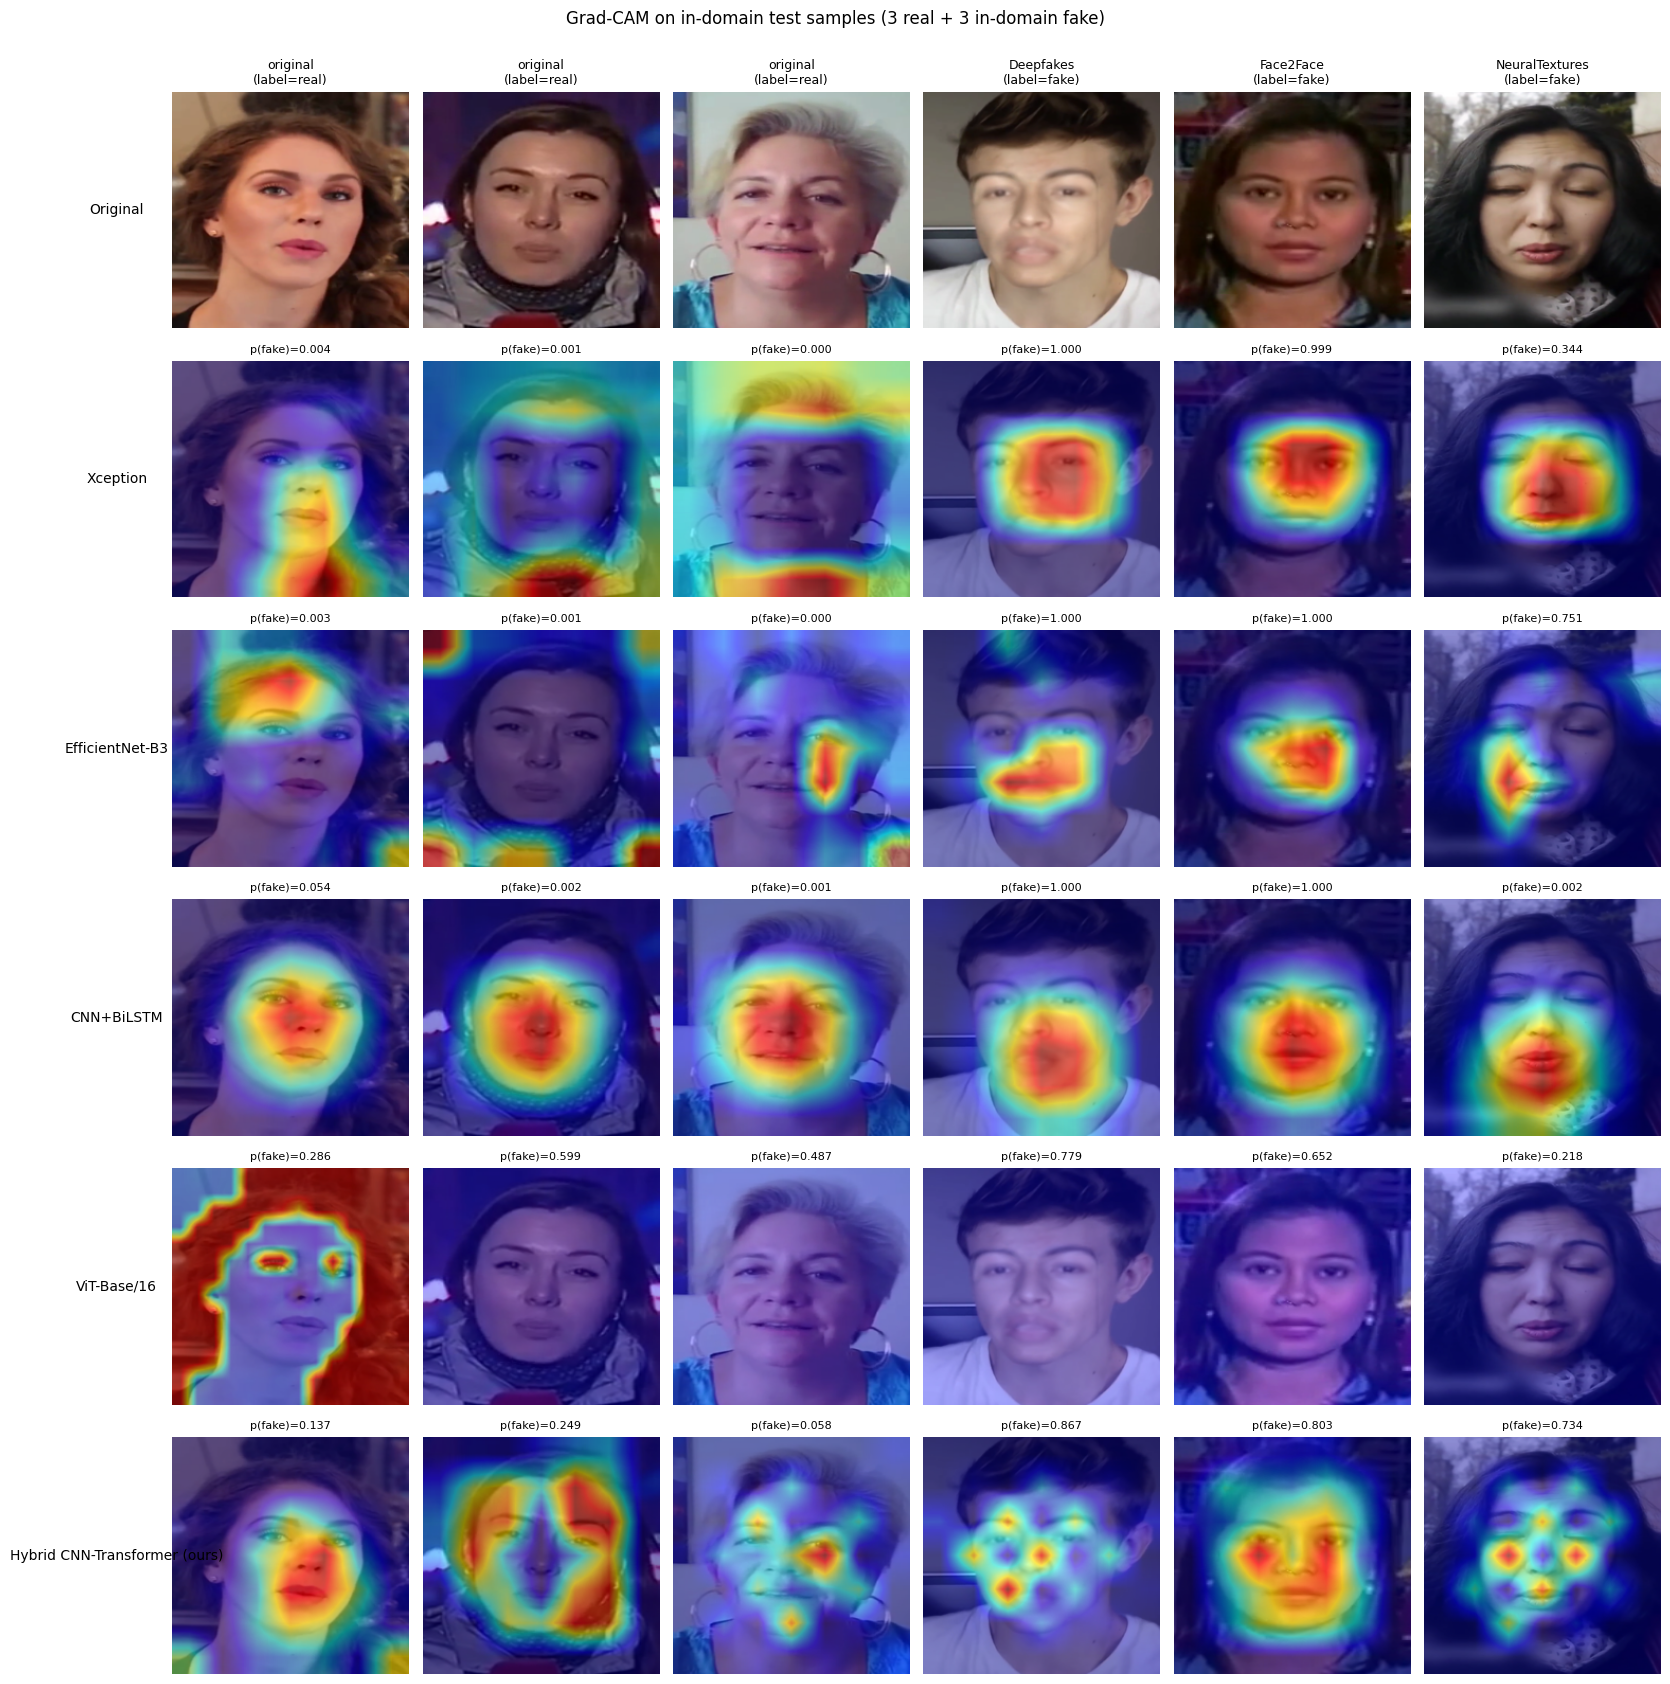

In [21]:
# In-domain grid: positions 0,1,2 are real; positions 3,4,5 are in-domain fakes
in_domain_positions = list(range(0, 6))
build_grid_figure(
    all_results,
    sample_positions=in_domain_positions,
    title="Grad-CAM on in-domain test samples (3 real + 3 in-domain fake)",
    save_path=output_dir_path / "grid_in_domain.png",
)

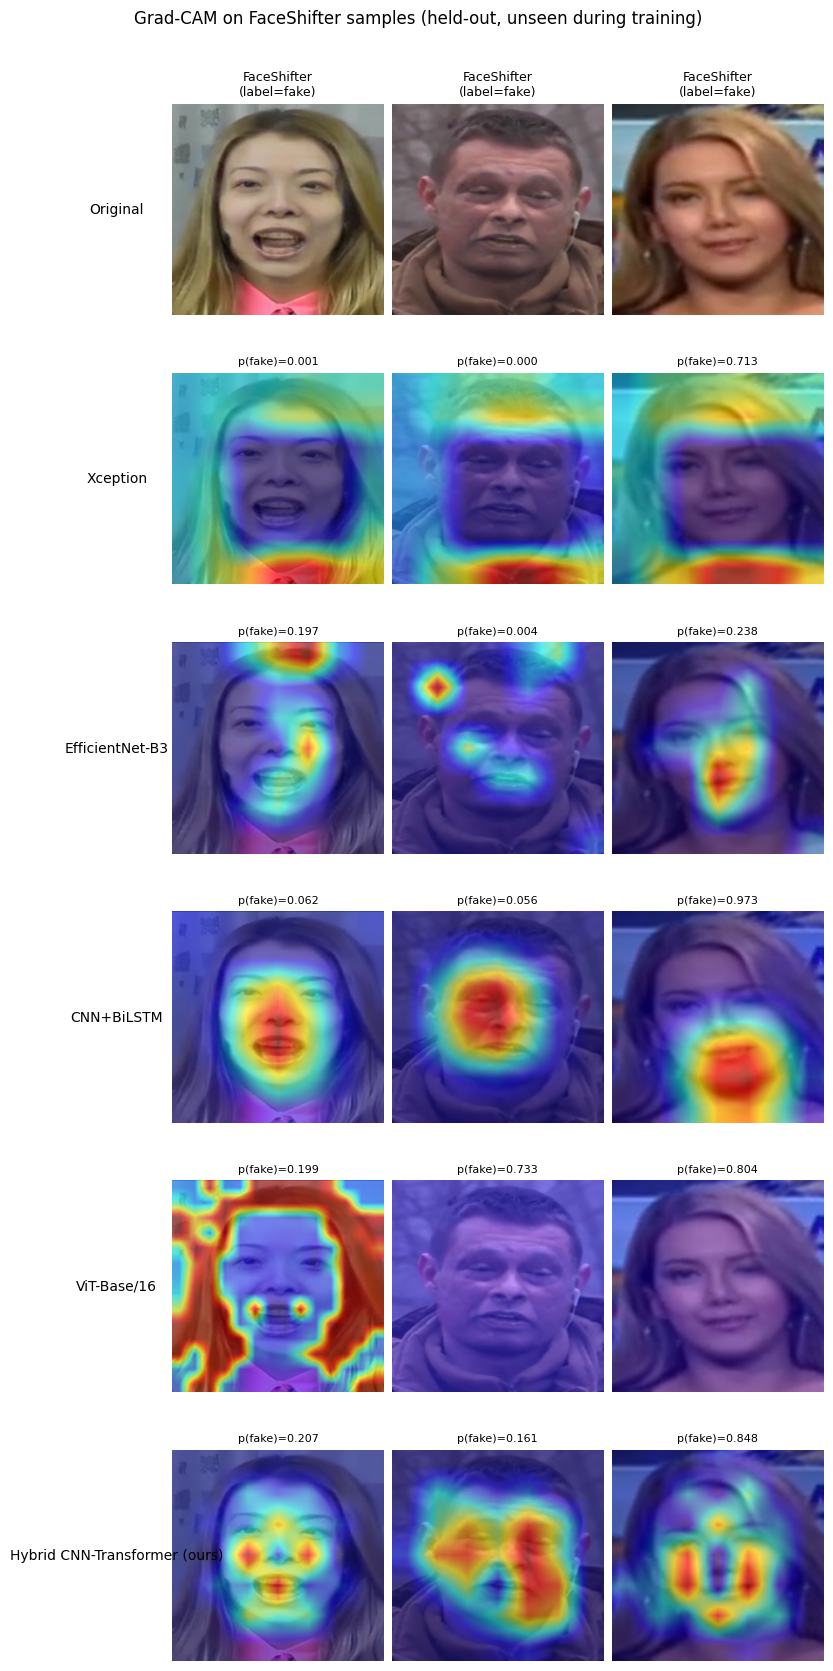

In [22]:
# FaceShifter grid: positions 6,7,8 are the FaceShifter (heldout) samples
faceshifter_positions = list(range(6, 9))
build_grid_figure(
    all_results,
    sample_positions=faceshifter_positions,
    title="Grad-CAM on FaceShifter samples (held-out, unseen during training)",
    save_path=output_dir_path / "grid_faceshifter.png",
)

# 10. Save results

In [23]:
summary_payload = {}
for model_name, model_block in all_results.items():
    summary_payload[model_name] = {
        "display_label": model_block["display_label"],
        "per_sample": [
            {
                "source": ps["source"],
                "sample_index": ps["sample_index"],
                "class_name": ps["class_name"],
                "label": ps["label"],
                "clip_probability": ps["clip_probability"],
            }
            for ps in model_block["per_sample"]
        ],
    }

summary_save_path = output_dir_path / "grad_cam_summary.json"
with open(summary_save_path, "w") as f:
    json.dump(summary_payload, f, indent=2)
